In [1]:
# Theoretical and Real AVO analysis using raw seismic data from KOPRI
# Zachary Katz
# 27 November 2025

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from obspy.io.segy.core import _read_segy
import os
import pandas as pd

############
# Number of shots on this Line [X=56, Y=40, XX=28. YY=20]
line = '21Y'
geometry_path = './_data/KPDC_David_Seismic_2022/RAW/21Y-Geometry.csv' 
sgy_file = './_data/KPDC_David_Seismic_2022/RAW/21Y'
############

geometry = pd.read_csv(geometry_path)
num_shots = np.max(geometry["SHOT_POINT"])

sgy_path = sgy_file + '.sgy'

def segyload_obspy(sgy_path, fldr_number=1):
    # Load entire SEG-Y file
    st = _read_segy(sgy_path, unpack_trace_headers=True)

    # Sampling values
    dt = st[0].stats.delta          # seconds
    ns = st[0].stats.npts
    time = np.arange(ns) * dt       # seconds

    # Select traces based on Field Record Number (fldr)
    selected_traces = []
    coords = {'source_x': [], 'source_y': [], 'group_x': [], 'group_y': []}
    for tr in st:
        hdr = tr.stats.segy.trace_header
        if hdr.original_field_record_number == fldr_number:
            selected_traces.append(tr.data)
            coords['source_x'].append(hdr.source_coordinate_x)
            coords['source_y'].append(hdr.source_coordinate_y)
            coords['group_x'].append(hdr.group_coordinate_x)
            coords['group_y'].append(hdr.group_coordinate_y)

    #if len(selected_traces) == 0:
    #    raise ValueError(f"No traces found for fldr={fldr_number}")

    data = np.stack(selected_traces)
    n_traces = data.shape[0]
    

    # Percentile clipping
    #lower_clip = np.percentile(data, 0.05)
    #upper_clip = np.percentile(data, 99.95)
    #data_clipped = np.clip(data, lower_clip, upper_clip)
    data_clipped = data

    # Transpose to (ns, n_traces) like segyio version
    data_clipped = data_clipped.T

    return data_clipped, time, n_traces, coords


data_arr = {'data_clipped': [], 'time': [], 'n_traces': [], 'coords': []}
for fldr_number in range(1,num_shots+1):
    print(fldr_number)
    data_clipped, time, n_traces, coords = segyload_obspy(sgy_path, fldr_number)
    data_arr['data_clipped'].append(data_clipped)
    data_arr['time'].append(time)
    data_arr['n_traces'].append(n_traces)
    data_arr['coords'].append(coords)


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40


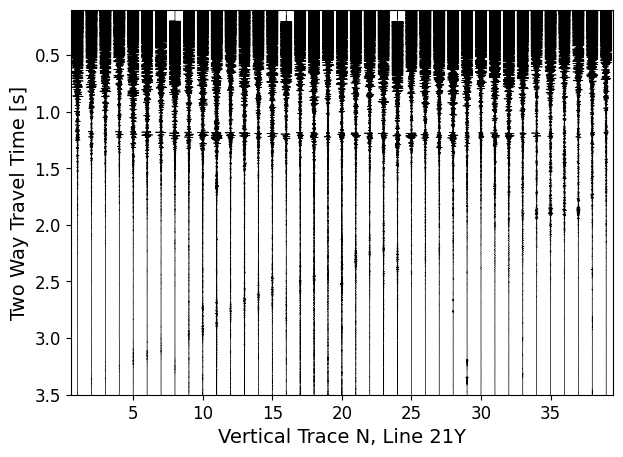

In [2]:
fig, ax = plt.subplots(figsize=(7, 5))
for index, fldr_number in enumerate(range(2,num_shots+1)):
    subset_geometry = geometry[geometry["SHOT_POINT"] == fldr_number].reset_index(drop=True)
    dist = np.array([np.sqrt((subset_geometry['XSHOT'][i]-subset_geometry['XREC'][i])**2 + (subset_geometry['YSHOT'][i]-subset_geometry['YREC'][i])**2 ) for i in range(len(subset_geometry['XSHOT']))])
    # Extract the correct shot to plot
    min_idx = np.argmin(dist) 

    vert_trace = data_arr['data_clipped'][index][:,min_idx]
    # clip vertical trace to be +/- 1
    #vert_trace = vert_trace * 2
    vert_trace = np.clip(vert_trace, -0.4, 0.4)
    x = index * np.ones_like(vert_trace) + vert_trace + 1
    time = data_arr['time'][index]

    ax.plot(x, time, color='k', linewidth=0.5)
    ax.set_xlim(0.5,39.5)
    ax.set_ylim(3.5,0.1)
    ax.set_xlabel("Vertical Trace N, Line 21Y",fontsize=14)
    ax.set_ylabel("Two Way Travel Time [s]",fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)


In [3]:
data_arr['data_clipped'][0].shape
line = '21YY'

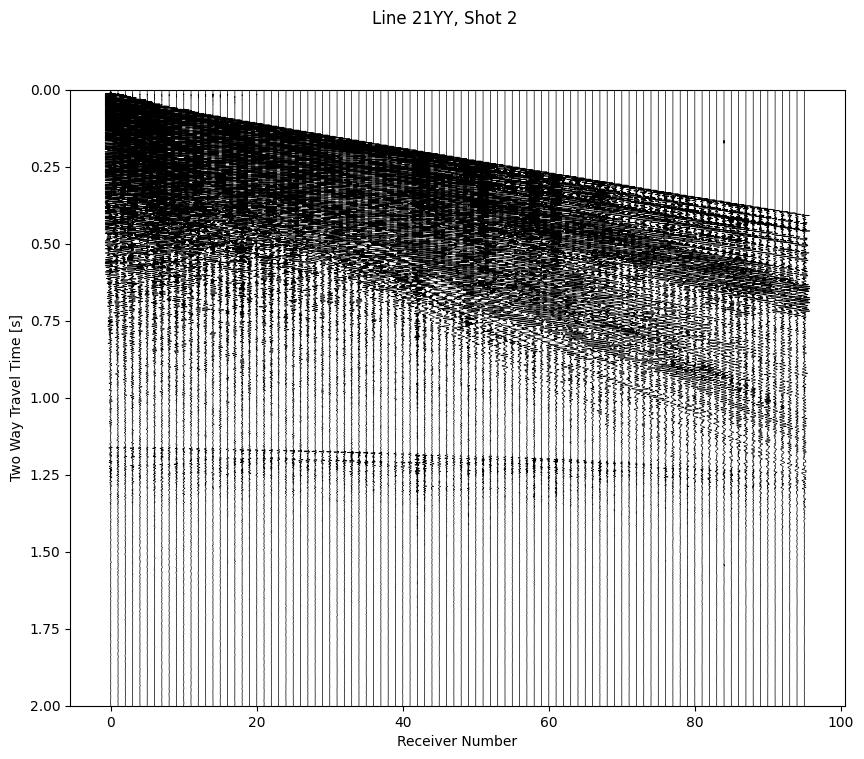

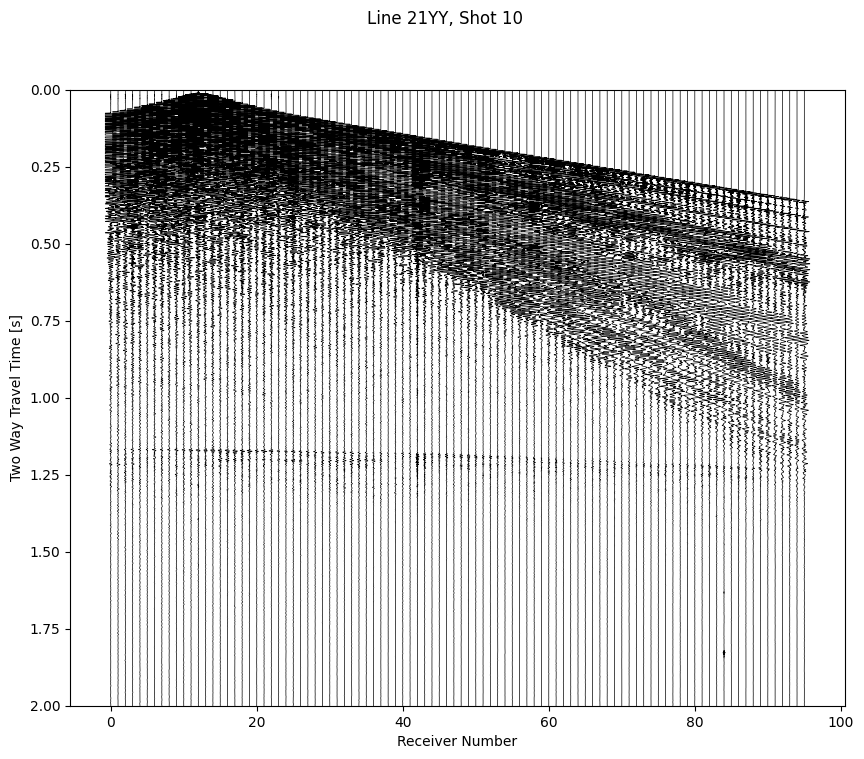

In [64]:
for index, fldr_number in enumerate([2,10]):
    fig, ax = plt.subplots(figsize=(10, 8))
    subset_geometry = geometry[geometry["SHOT_POINT"] == fldr_number].reset_index(drop=True)

    time = data_arr['time'][index]
    traces = data_arr['data_clipped'][index]
    for trace_no, trace in enumerate(traces.T):
        trace = np.clip(trace, -0.75, 0.75)
        x = trace_no * np.ones_like(trace) + trace
        ax.plot(x, time, color='k', linewidth=0.5)

    ax.set_ylim(2,0)
    #ax.set_ylim(1.5,1)
    ax.set_xlabel("Receiver Number")
    ax.set_ylabel("Two Way Travel Time [s]")
    fig.suptitle(f"Line {line}, Shot {fldr_number}")


In [4]:
from PyAstronomy import pyasl

gnss1 = pyasl.decimalYearGregorianDate(2018.87897)
gnss2 = pyasl.decimalYearGregorianDate(2018.88034)
gnssN = pyasl.decimalYearGregorianDate(2019.85091)
print(gnss1, gnss2, gnssN)

2018-11-17 19:46:37.000920 2018-11-18 07:46:42.000240 2019-11-07 13:58:17.000760


In [5]:
file_path = './_data/GNSS'
gnss_records = []
for file in os.listdir(file_path):
    if file.endswith('.txt'):
        gnss_data = pd.read_csv(f'{file_path}/{file}',header=0, names=['time','x','y','z','detrended_z','v'])
        gnss_data['datetime'] = [pyasl.decimalYearGregorianDate(time) for time in gnss_data['time']]
        x0 = gnss_data['x'].iloc[0]
        y0 = gnss_data['y'].iloc[0]

        gnss_data['h_displacement'] = np.sqrt(
            (gnss_data['x'] - x0)**2 +
            (gnss_data['y'] - y0)**2
        )
        station = file.split('.')[0]
        gnss_data['station'] = station
        gnss_records.append(gnss_data)

gnss_records = sorted(gnss_records, key=lambda x: x['station'][0])

In [6]:
import shapefile
import cartopy.crs as ccrs
from pyproj import CRS, Transformer
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib as mpl

def ll2xy(lon: list[float], lat: list[float]) -> tuple[list[float], list[float]]:
    """
    Transform coordinates from input geodetic coordinates (lon, lat)
    to output Antarctic Polar Stereographic coordinates (x, y).
    Can also take single floats.

    Parameters
    ----------
    lon: list[float]
         Geodetic longitude in EPSG:4326
    lat: list[float]
         Geodetic latitude in EPSG:4326

    Returns
    -------
    x: list[float]
       Antarctic Polar Stereographic (EPSG:3031) x
    y: list[float]
       Antarctic Polar Stereographic (EPSG:3031) y
    """

    crs_ll = CRS("EPSG:4326")
    crs_xy = CRS("EPSG:3031")
    ll_to_xy = Transformer.from_crs(crs_ll, crs_xy, always_xy=True)
    x, y = ll_to_xy.transform(lon, lat)
    return x, y

/tmp/ipykernel_8873/2999481916.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")
/tmp/ipykernel_8873/2999481916.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")
/tmp/ipykernel_8873/2999481916.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


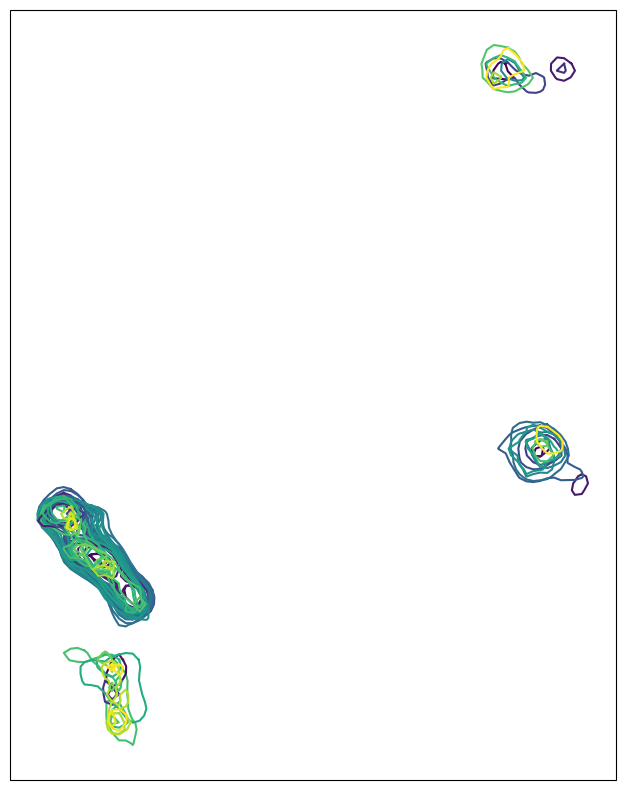

In [16]:
# Load Wilson Outline for SLD1,2
import geopandas as gpd
import matplotlib.cm as cm
import matplotlib.colors as colors

ps71_projection = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)
fig, ax = plt.subplots(
    figsize=(10, 10),
    subplot_kw={'projection': ps71_projection},
)

paths = ['./_data/EvolvingOutlines/David_s1.geojson','./_data/EvolvingOutlines/David_s2.geojson','./_data/EvolvingOutlines/David_s3.geojson']
for evolving_path in paths:
    evolving_outlines = gpd.read_file(evolving_path)
    times = evolving_outlines["mid_pt_datetime"]

    # Convert datetimes → numeric (float seconds)
    t_num = np.array(times.astype("int64"))  # nanoseconds since epoch

    # Normalize to 0–1 range for the colormap
    norm = colors.Normalize(vmin=t_num.min(), vmax=t_num.max())
    cmap = cm.get_cmap("viridis")


    for outline, time in zip(evolving_outlines['geometry'], t_num):
        x_evolve, y_evolve = outline.exterior.xy
        color = cmap(norm(time))
        ax.plot(x_evolve, y_evolve, color=color)


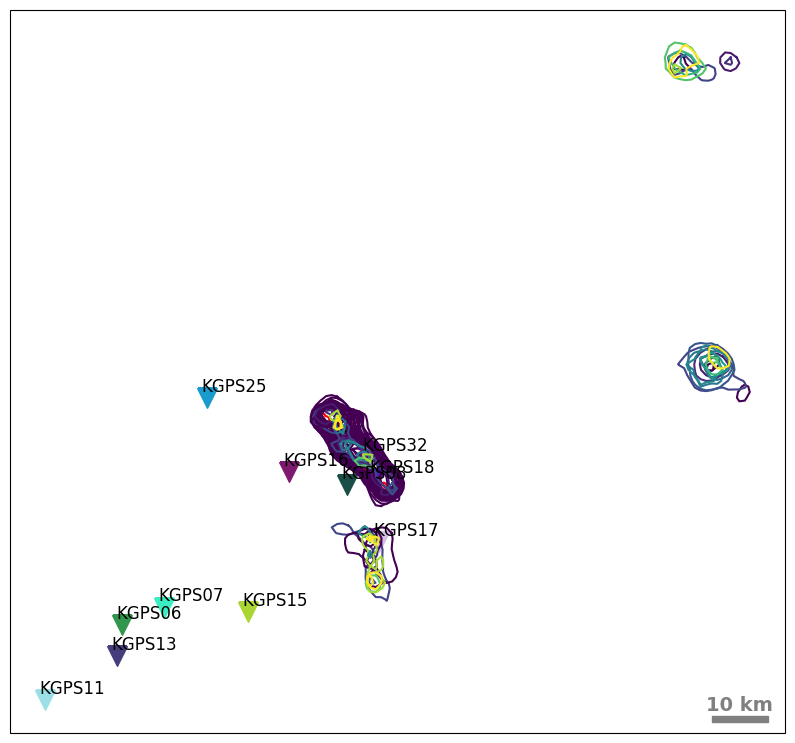

In [ ]:
ps71_projection = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)
fig, ax = plt.subplots(
    figsize=(10, 10),
    subplot_kw={'projection': ps71_projection},
)
colors = ['#32964d', '#39eec0', '#194f46', '#9be0e6', '#453e7d', '#abd533', '#7d1a6e', '#d6bee2', '#501bbf', '#199bce', '#ffa8ff']
for color, gnss_data in zip(colors, gnss_records):
    #ax.scatter(gnss_data['x'],gnss_data['y'],c=gnss_data['time'])
    ax.scatter(gnss_data['x'][0],gnss_data['y'][0],color=color, marker='v', s=200)
    ax.text(gnss_data['x'][0]-1000,gnss_data['y'][0]+1200,gnss_data['station'][0], color='black', fontsize=12)
# Load and plot lake and seismic outlines
# Load Lake Cheongsuk shapefile
sld_path = '/mnt/c/Users/ZacharyKatz/Desktop/Research/_Semesters/25FA/KOPRI/SLD2'
pathA = sld_path + '/SLD2-A.shp'
pathB = sld_path + '/SLD2-B.shp'
pathC = sld_path + '/SLD2-C.shp'

xs = []
ys = []
for path in [pathA, pathB, pathC]:
    sf = shapefile.Reader(path)
    shapes = sf.shapes()
    for shp in shapes:
        points = shp.points
        x = [p[0] for p in points]
        y = [p[1] for p in points]
    xs.append(x)
    ys.append(y)

# Load seismic data
seismic_path = '../atl11-crossovers/_data/SeismicKSS2_21-22.csv'
seismic = pd.read_csv(seismic_path)
seismic['x'], seismic['y'] = ll2xy(seismic['LONGITUDE'], seismic['LATITUDE'])


for x, y in zip(xs, ys):
    ax.plot(x, y, color='red', linewidth=1.5)
ax.scatter(seismic['Shot_X'], seismic['Shot_Y'], s=1, c='black', label='Seismic Shots', transform=ps71_projection)
bbox = [615000,-1475000,715000,-1425000] #David_SGL2
#ax.set_xlim(bbox[0],bbox[2])
#ax.set_ylim(bbox[1],bbox[3])

scalebar = AnchoredSizeBar(ax.transData,
                           10000, '10 km', 'lower right', 
                           pad=0.1,
                           sep=1,
                           color='Gray',
                           frameon=False,
                           size_vertical=1000,
                           fontproperties=mpl.font_manager.FontProperties(size=14, weight='bold'),
                           label_top=True)

ax.add_artist(scalebar)
scalebar.set_bbox_to_anchor((0.99, 0.01), transform=ax.transAxes)

"""
paths = ['./_data/EvolvingOutlines/David_s1.geojson','./_data/EvolvingOutlines/David_s2.geojson','./_data/EvolvingOutlines/David_s3.geojson']
for evolving_path in paths:
    evolving_outlines = gpd.read_file(evolving_path)
    times = evolving_outlines["mid_pt_datetime"]

    # Convert datetimes → numeric (float seconds)
    t_num = np.array(times.astype("int64"))  # nanoseconds since epoch

    for outline, time in zip(evolving_outlines['geometry'], t_num):
        x_evolve, y_evolve = outline.exterior.xy
        color = cmap(norm(time))
        ax.plot(x_evolve, y_evolve, color=color)
"""

In [8]:
for record in gnss_records:
    print(record['station'][0])

KGPS06
KGPS07
KGPS08
KGPS11
KGPS13
KGPS15
KGPS16
KGPS17
KGPS18
KGPS25
KGPS32


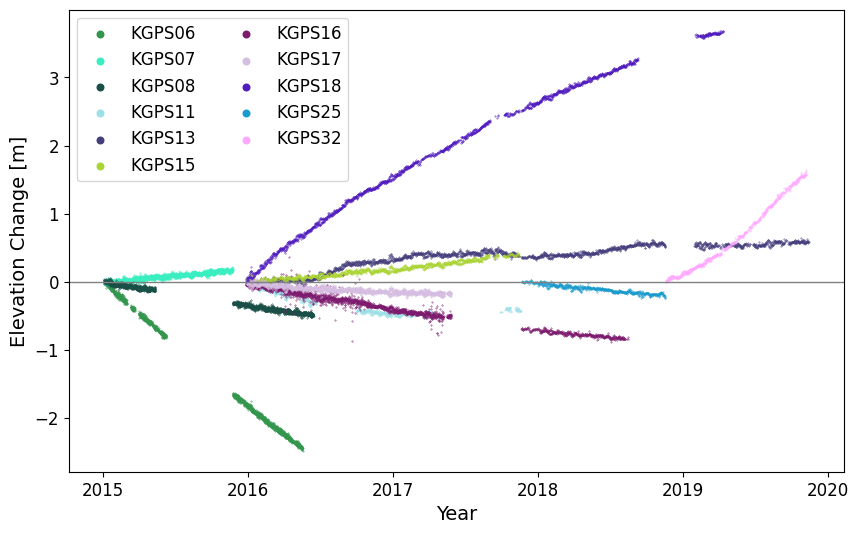

In [9]:
# Change in elevation v time for all stations
fig, ax = plt.subplots(figsize=(10, 6))

ax.axhline(0, color='gray', linestyle='-', linewidth=1)
colors = ['#32964d', '#39eec0', '#194f46', '#9be0e6', '#453e7d', '#abd533', '#7d1a6e', '#d6bee2', '#501bbf', '#199bce', '#ffa8ff']
for gnss_data, color in zip(gnss_records, colors):
    ax.scatter(gnss_data['datetime'], gnss_data['z'] - gnss_data['z'][0], label=gnss_data['station'][0], color=color, s=0.1)

ax.legend(fontsize=12, markerscale=15,ncol=2)

ax.set_xlabel("Year", fontsize=14)
ax.set_ylabel("Elevation Change [m]", fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=12)


In [19]:
import scipy
# Find instantaneous velocity and smooth
def derivative(time, x_col, freq):
    """
    Compute the first and second derivative of a smoothed time series
    Parameters
    time - event with times
    x_col - column of x values of which to take the derivative of

    Returns
    grad - First derivative [list]
    grad2 - Second derivative [list]
    """
    y_data = x_col - np.mean(x_col)
    # print(x_data,y_data)
    try:
        b, a = scipy.signal.butter(4, freq, "low")
        filtered = scipy.signal.filtfilt(b, a, y_data, padlen=50)
        grad = np.gradient(filtered, 60*12)

        b, a = scipy.signal.butter(4, 0.05)
        grad_filtered = scipy.signal.filtfilt(b, a, grad, padlen=50)
        grad2 = np.gradient(np.gradient(grad_filtered), 60*12)
    except ValueError:
        grad = np.full(len(y_data), np.nan)
        grad2 = np.full(len(y_data), np.nan)
    return grad, grad2



In [31]:

v_float = gnss_data['v'].astype(float)
~np.isnan(v_float)

0       True
1       True
2       True
3       True
4       True
        ... 
1866    True
1867    True
1868    True
1869    True
1870    True
Name: v, Length: 1871, dtype: bool

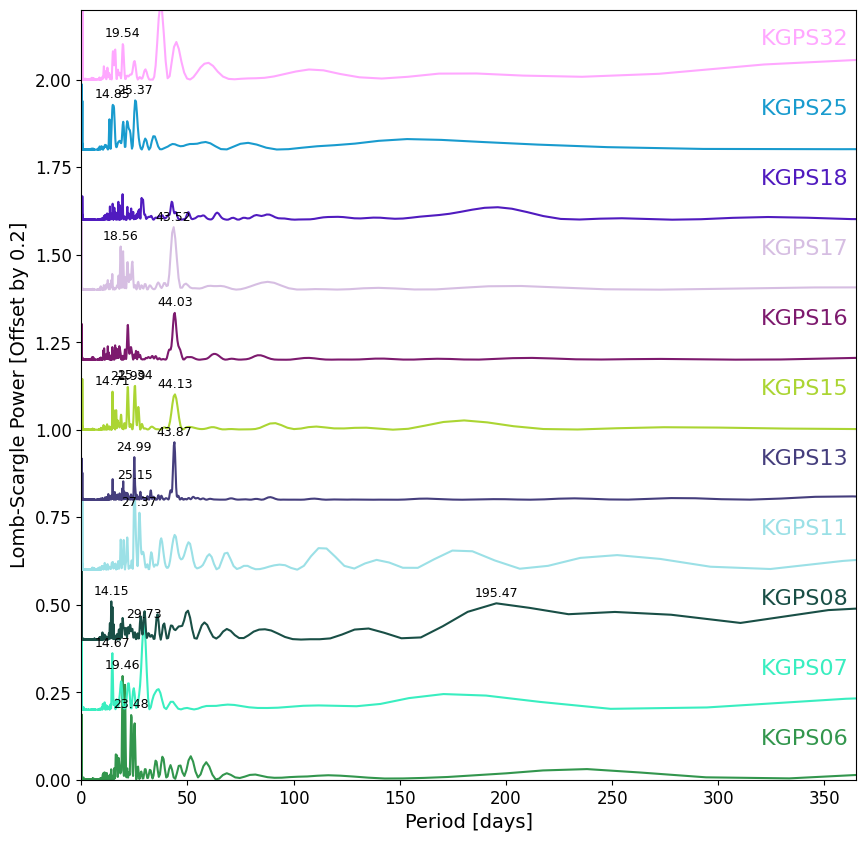

In [44]:
from astropy.timeseries import LombScargle

fig, ax = plt.subplots(figsize=(10, 10),)
offset=0
for color, gnss_data in zip(colors, gnss_records):
    g1, g2 = derivative(gnss_data['time'], gnss_data["h_displacement"], 0.05)
    gnss_data['velocity'] = g1
    
    """
    fig, ax = plt.subplots(
        figsize=(10, 10),
    )
    gnss_data['velocity'] = g1
    ax.scatter(gnss_data['datetime'],gnss_data['velocity'] )
    ax.set_xlabel('Datetime')
    ax.set_ylabel('V [m/day]')
    """

    # Lomb scargke of datetune vel
    from astropy.timeseries import LombScargle
    # Convert datetime to seconds
    dates_as_sec_from2015 = np.array([(dt - pd.Timestamp('2015-01-01')).total_seconds() for dt in gnss_data['datetime']])
    # Mask NaN values

    v_float = gnss_data['v'].astype(float)
    mask = ~np.isnan(v_float)
    dates_as_sec_masked = dates_as_sec_from2015[mask]
    avg_vel_detrended = v_float[mask]

    velocity = gnss_data['v']
    frequency, power = LombScargle(dates_as_sec_masked, avg_vel_detrended).autopower()
    period = 1 / frequency / 3600 / 24  # days
    ax.plot(period, power + offset, color=color, label=gnss_data['station'][0])
    ax.text(320, offset + 0.1, gnss_data['station'][0], color=color, fontsize=16)

    # Pick peak on power
    peaks, props = scipy.signal.find_peaks(power, height=0.1, distance=10)
    for i in peaks:
        if (period[i]) > 5:
            ax.annotate(
            f"{period[i]:.2f}",              # format as needed
            (period[i], power[i]+offset),
            xytext=(0, 5),
            textcoords='offset points',
            ha='center',
            fontsize=9
        )
        

    offset += 0.2


    ax.set_xlim(0, 365)
    ax.set_ylim(0,2.2)

    ax.set_xlabel("Period [days]", fontsize=14)
    ax.set_ylabel("Lomb-Scargle Power [Offset by 0.2]", fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)


TypeError: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

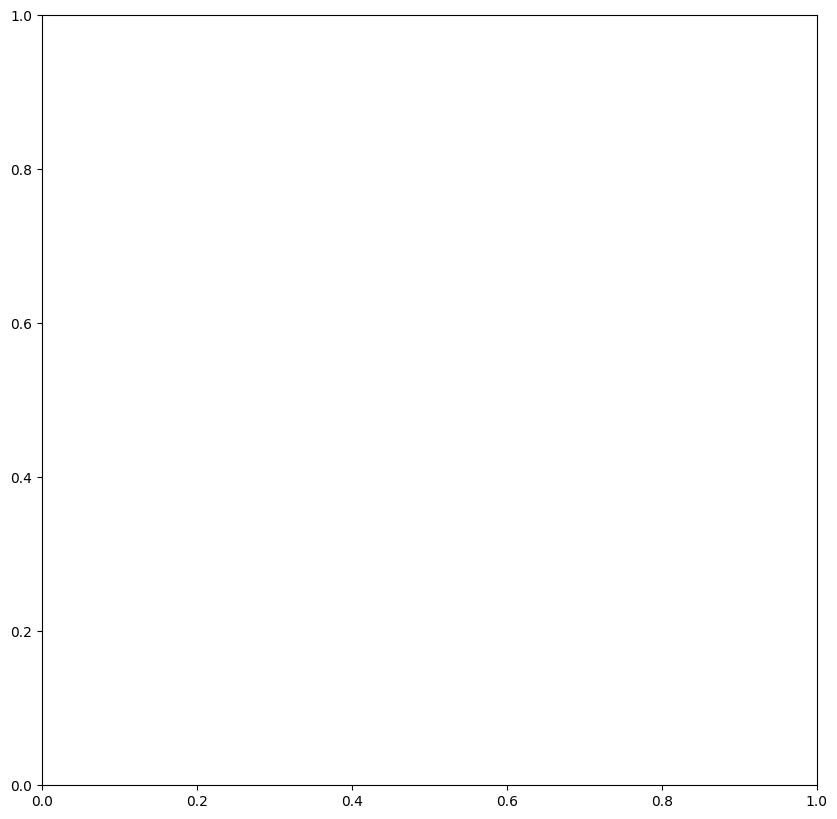

In [ ]:
from astropy.timeseries import LombScargle

fig, ax = plt.subplots(figsize=(10, 10),)
offset=0
for color, gnss_data in zip(colors, gnss_records):
    g1, g2 = derivative(gnss_data['time'], gnss_data["h_displacement"], 0.05)
    gnss_data['velocity'] = g1
    
    """
    fig, ax = plt.subplots(
        figsize=(10, 10),
    )
    gnss_data['velocity'] = g1
    ax.scatter(gnss_data['datetime'],gnss_data['velocity'] )
    ax.set_xlabel('Datetime')
    ax.set_ylabel('V [m/day]')
    """

    # Lomb scargke of datetune vel
    from astropy.timeseries import LombScargle
    # Convert datetime to seconds
    dates_as_sec_from2015 = np.array([(dt - pd.Timestamp('2015-01-01')).total_seconds() for dt in gnss_data['datetime']])
    # Mask NaN values
    mask = ~np.isnan(gnss_data['velocity'])
    dates_as_sec_masked = dates_as_sec_from2015[mask]
    avg_vel_detrended = gnss_data['velocity'][mask]

    velocity = gnss_data['velocity']
    frequency, power = LombScargle(dates_as_sec_masked, avg_vel_detrended).autopower()
    period = 1 / frequency / 3600 / 24  # days
    ax.plot(period, power + offset, color=color, label=gnss_data['station'][0])
    ax.text(320, offset + 0.1, gnss_data['station'][0], color=color, fontsize=16)
    offset += 0.2

    ax.set_xlim(0, 365)
    ax.set_ylim(0,2.2)

    ax.set_xlabel("Period [days]", fontsize=14)
    ax.set_ylabel("Lomb-Scargle Power [Offset by 0.2]", fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)
